# Method B: Further Work

Everything built on top of the streams and signatures from `notebook_method_b_streams.ipynb`:
the distance function and sanity check, two rounds of adversarial evaluation (a merged
496-dim distance, then a per-path approach that replaced it), the diagnostics that motivated
that change, a robustness check on the result, and a hyperparameter sweep that found a better
configuration than the original default. Sections are ordered chronologically to show how
the approach evolved; earlier, superseded steps are kept brief.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

%load_ext autoreload
%autoreload 2

%matplotlib inline
import json
import matplotlib.pyplot as plt
from IPython.display import display

from signature_distance import (
    method_b_adversarial_eval as mbae,
    method_b_sweep as sweep,
    per_line_diagnostics,
    per_path_adversarial_eval as ppae,
    plots,
    run_experiment,
)
from signature_distance.streams import make_reference_lines

## Distance function and sanity check

Each line's signature is rescaled level-`n` by `r**n` (raw coefficients decay ~1/n! with
depth) and the 16 rescaled per-line signatures are concatenated into one 496-dim feature
vector per image. Within-digit vs. cross-digit mean distance on a 300-image sample:

In [2]:
sanity = run_experiment.sanity_check_demo(n_per_class=30, seed=0)
print(json.dumps(sanity['method_b'], indent=2))

{
  "r": 2.8597598377587485,
  "raw": {
    "within_digit_mean": 0.8844699859619141,
    "cross_digit_mean": 1.0520490407943726,
    "ratio_cross_over_within": 1.189468334134828
  },
  "rescaled": {
    "within_digit_mean": 28.5981388092041,
    "cross_digit_mean": 33.16693115234375,
    "ratio_cross_over_within": 1.1597583805582905
  }
}


Within-digit pairs were closer than cross-digit pairs (ratio ~1.16), so the distance
was behaving sensibly - but only about as well as plain raw-pixel Euclidean distance
(~1.13), not clearly better. This motivated testing it on the actual task it was built
for (adversarial/Lipschitz-ratio evaluation) rather than tuning further on this weak signal
alone.

## Round 1: merged-distance adversarial evaluation

FGSM perturbations against two freshly trained classifiers (SmallCNN, StrongCNN),
comparing the Lipschitz ratio (margin change / distance) under the merged 496-dim Method B
distance vs. plain pixel-Euclidean, against a magnitude-matched random-noise control.

In [3]:
merged_result = mbae.run_adversarial_evaluation(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)
for name, mres in merged_result['models'].items():
    print(f"{name}: test_acc={mres['test_acc']:.4f}")
    for eps, e in mres['eps'].items():
        ra = e['ratio_a_adv'].mean().item() / e['ratio_a_control'].mean().item()
        rb = e['ratio_b_adv'].mean().item() / e['ratio_b_control'].mean().item()
        print(f"  eps={eps}: pixel adv/ctrl={ra:.2f}x  Method B adv/ctrl={rb:.2f}x")

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: train_acc=0.9829 test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: train_acc=0.9936 test_acc=0.9936


SmallCNN: test_acc=0.9824
  eps=0.02: pixel adv/ctrl=9.11x  Method B adv/ctrl=7.42x
  eps=0.03: pixel adv/ctrl=8.47x  Method B adv/ctrl=7.04x
  eps=0.05: pixel adv/ctrl=8.46x  Method B adv/ctrl=7.20x
StrongCNN: test_acc=0.9936
  eps=0.02: pixel adv/ctrl=5.04x  Method B adv/ctrl=4.55x
  eps=0.03: pixel adv/ctrl=4.39x  Method B adv/ctrl=3.76x
  eps=0.05: pixel adv/ctrl=3.62x  Method B adv/ctrl=3.25x


Both distances separated adversarial from control pairs clearly, but Method B's
separation ratio was consistently a little behind plain pixel-Euclidean's, on both models,
at every epsilon - the merged 496-dim distance wasn't beating the baseline it was meant to
improve on.

Distributions for one representative model and epsilon (SmallCNN, eps=0.03) - the
overlap between adversarial and control histograms is what "separates clearly" actually
looks like.

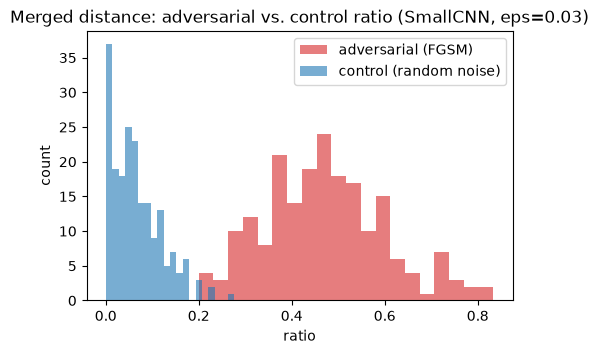

In [4]:
e = merged_result['models']['SmallCNN']['eps'][0.03]
fig = plots.plot_ratio_distribution(
    e['ratio_b_adv'], e['ratio_b_control'],
    title="Merged distance: adversarial vs. control ratio (SmallCNN, eps=0.03)")
display(fig)
plt.close(fig)

## Diagnostic: does concatenation dilute a strong per-line signal?

Same/different-digit AUC, computed per individual line and compared against the merged
distance, on the same 300-image sample.

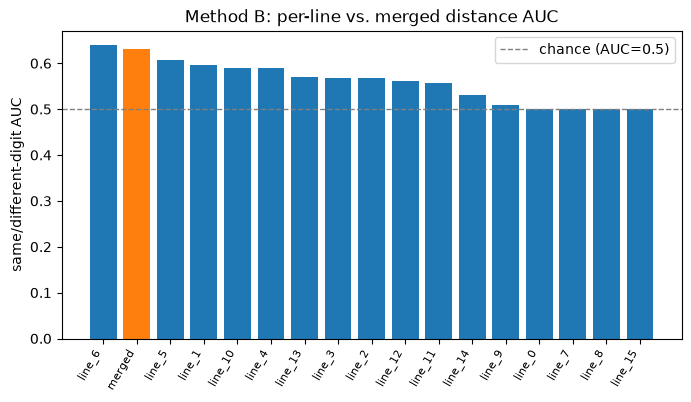

best line: line_6 (AUC=0.6394) vs merged (AUC=0.6315)
lines at chance level (AUC~0.5): ['line_0', 'line_7', 'line_8', 'line_15']


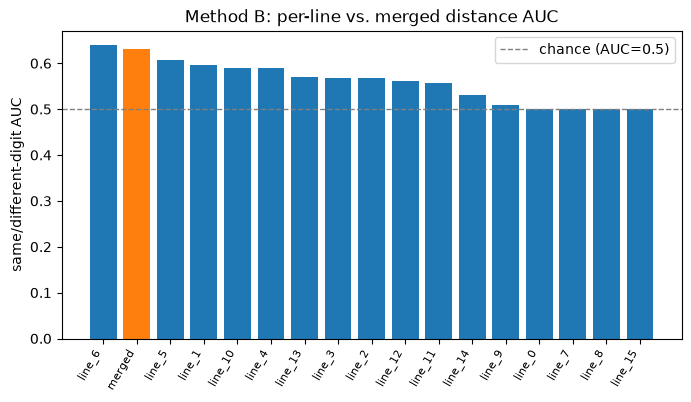

In [5]:
diag = per_line_diagnostics.run_per_line_auc_diagnostic(n_per_class=30, seed=0)
fig = plots.plot_per_line_auc_ranking(diag['ranked'])
display(fig)
print(f"best line: {diag['ranked'][0][0]} (AUC={diag['ranked'][0][1]['auc']:.4f}) vs merged (AUC={diag['measures']['merged']['auc']:.4f})")
print(f"lines at chance level (AUC~0.5): {[name for name, e in diag['measures'].items() if e['auc'] <= 0.505]}")

One line narrowly beat the merged distance; 4 of 16 lines (running exactly along the image
border, where MNIST digits essentially never reach) carried zero signal. This pointed at two
things worth testing directly: whether keeping paths separate (never merging) does better
than concatenation, and whether line placement could be improved.

## Round 2: per-path adversarial evaluation (the pivot)

Instead of one merged distance, each of the 16 reference lines produces its own local
Lipschitz ratio - examined as a collection, the way the pixel-space Lipschitz work treats
individual pixels, never reduced to a single number.

In [6]:
results = ppae.run_per_path_adversarial_eval(
    n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)
for name, mres in results['models'].items():
    print(f"{name}: test_acc={mres['test_acc']:.4f}")

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


  epoch 1/3  train loss 0.1923


  epoch 2/3  train loss 0.0574


  epoch 3/3  train loss 0.0448


  StrongCNN: test_acc=0.9936


SmallCNN: test_acc=0.9824
StrongCNN: test_acc=0.9936


In [7]:
summary = ppae.summarize_informative_subset(results)

for name in results['models']:
    for eps in results['epsilons']:
        s = summary[name][eps]
        fold_ratios = [
            s['per_line'][i]['mean_ratio_adv_flipped'] / s['per_line'][i]['mean_ratio_control_matched']
            for i in ppae.INFORMATIVE_LINE_INDICES
            if s['per_line'][i]['mean_ratio_adv_flipped'] is not None
        ]
        if not fold_ratios:
            print(f"{name} eps={eps}: no flips")
            continue
        mean_fold = sum(fold_ratios) / len(fold_ratios)
        print(f"{name} eps={eps}: n_flipped={s['n_flipped']}/{results['n_images']}  mean fold-ratio (adv/control, 12 lines)={mean_fold:.2f}x")

SmallCNN eps=0.02: n_flipped=7/200  mean fold-ratio (adv/control, 12 lines)=10.81x
SmallCNN eps=0.03: n_flipped=8/200  mean fold-ratio (adv/control, 12 lines)=9.36x
SmallCNN eps=0.05: n_flipped=14/200  mean fold-ratio (adv/control, 12 lines)=10.54x
StrongCNN eps=0.02: n_flipped=4/200  mean fold-ratio (adv/control, 12 lines)=11.27x
StrongCNN eps=0.03: n_flipped=5/200  mean fold-ratio (adv/control, 12 lines)=4.18x
StrongCNN eps=0.05: n_flipped=9/200  mean fold-ratio (adv/control, 12 lines)=4.18x


For every one of the 12 informative lines, in every one of the 6 model x epsilon
combinations (72/72, no exceptions), the adversarial ratio exceeded the matched control
ratio - mean fold-ratios of 4-11x, clearer separation than the merged distance's own
7.0-7.4x / 3.3-4.6x. A secondary check (entropy of which line spikes) found adversarial
perturbations concentrate on fewer paths than equally-large random noise, in all 6/6 cases
- modest, but zero exceptions. A confound was identified and checked directly rather than
assumed away: two lines dominated raw spike counts under both adversarial *and* control
conditions, because of a generic smaller baseline distance, not adversarial specificity.

Per-line fold-ratio for one representative model and epsilon (SmallCNN, eps=0.03), and
the full ratio distribution for the single best-performing line.

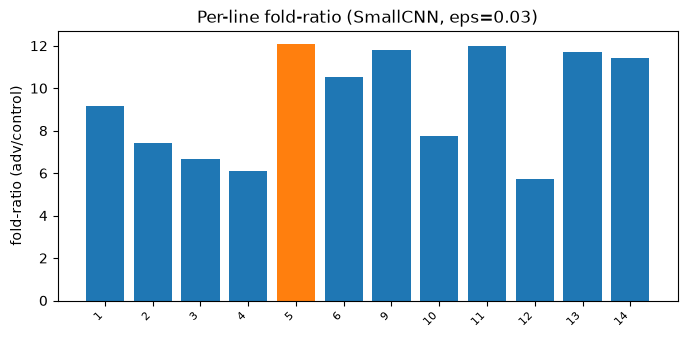

best line: 5 (12.09x)


In [8]:
s = summary['SmallCNN'][0.03]
fold_by_line = {
    i: s['per_line'][i]['mean_ratio_adv_flipped'] / s['per_line'][i]['mean_ratio_control_matched']
    for i in ppae.INFORMATIVE_LINE_INDICES
}
best_line = max(fold_by_line, key=fold_by_line.get)
fig = plots.plot_per_line_bar(
    fold_by_line, title="Per-line fold-ratio (SmallCNN, eps=0.03)",
    ylabel="fold-ratio (adv/control)", highlight_key=best_line,
)
display(fig)
plt.close(fig)
print(f"best line: {best_line} ({fold_by_line[best_line]:.2f}x)")

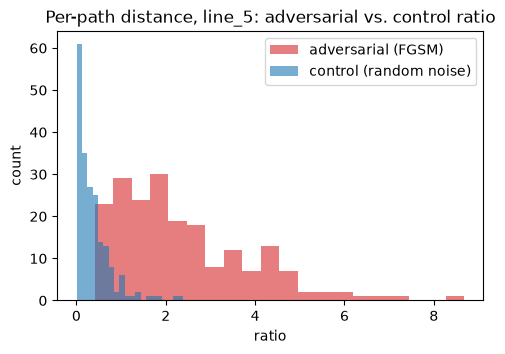

In [9]:
e = results['models']['SmallCNN']['eps'][0.03]
fig = plots.plot_ratio_distribution(
    e['ratio_adv'][:, best_line], e['ratio_control'][:, best_line],
    title=f"Per-path distance, line_{best_line}: adversarial vs. control ratio")
display(fig)
plt.close(fig)

Which single path spiked the most for two genuinely flipped pairs, shown directly on
the perturbed image.

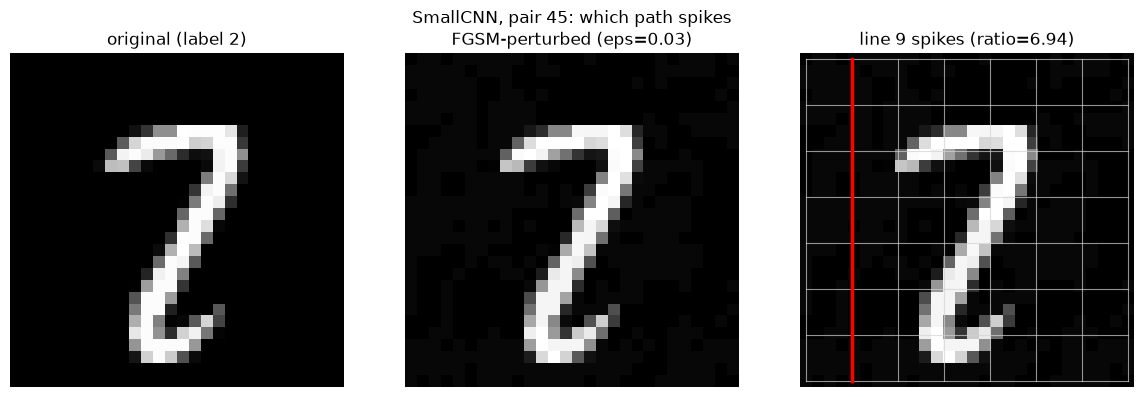

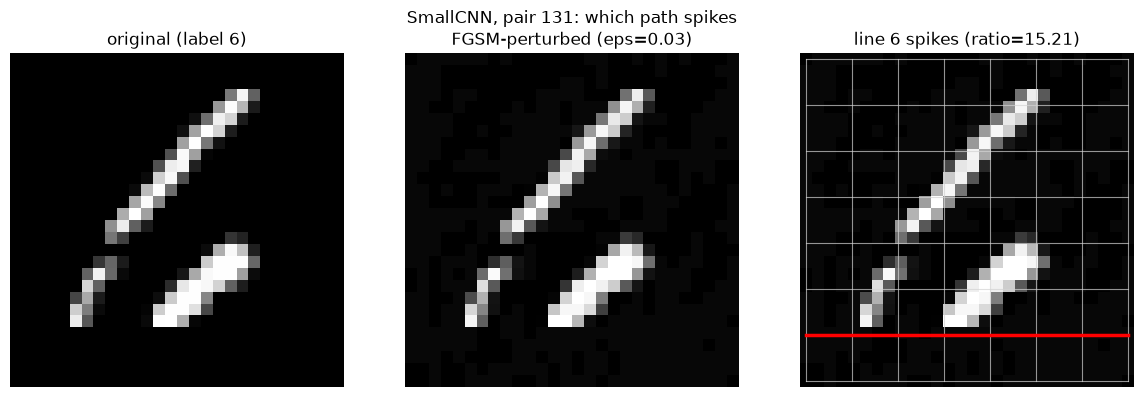

In [10]:
flip_idx = results['models']['SmallCNN']['eps'][0.03]['flip_mask'].nonzero(as_tuple=True)[0].tolist()
for pair_idx in flip_idx[:2]:
    fig = ppae.plot_spike_gallery(results, 'SmallCNN', 0.03, pair_idx=pair_idx)
    display(fig)
    plt.close(fig)

## Robustness check: does the finding depend on a small number of lines?

Reuses the `results` already computed above (no retraining) - excludes the two
confounded lines and checks whether the 72/72 pattern and fold-ratio magnitude survive.

In [11]:
robustness_report = ppae.fold_ratio_robustness(results)

for name, per_eps in robustness_report.items():
    for eps, r in per_eps.items():
        if r['n_flipped'] == 0:
            continue
        print(f"{name} eps={eps}: mean fold, 12 lines={r['mean_fold_12']:.2f}x  "
              f"10 lines (excl. confounded)={r['mean_fold_10']:.2f}x  "
              f"all 10 still adv>control={r['all_10_survive_adv_gt_control']}  "
              f"dist-fold correlation={r['dist_fold_correlation_10']:.3f}")

SmallCNN eps=0.02: mean fold, 12 lines=10.81x  10 lines (excl. confounded)=10.46x  all 10 still adv>control=True  dist-fold correlation=-0.320
SmallCNN eps=0.03: mean fold, 12 lines=9.36x  10 lines (excl. confounded)=8.91x  all 10 still adv>control=True  dist-fold correlation=-0.084
SmallCNN eps=0.05: mean fold, 12 lines=10.54x  10 lines (excl. confounded)=10.61x  all 10 still adv>control=True  dist-fold correlation=-0.181
StrongCNN eps=0.02: mean fold, 12 lines=11.27x  10 lines (excl. confounded)=11.80x  all 10 still adv>control=True  dist-fold correlation=0.117
StrongCNN eps=0.03: mean fold, 12 lines=4.18x  10 lines (excl. confounded)=4.16x  all 10 still adv>control=True  dist-fold correlation=0.032
StrongCNN eps=0.05: mean fold, 12 lines=4.18x  10 lines (excl. confounded)=4.27x  all 10 still adv>control=True  dist-fold correlation=-0.200


Removing the two confounded lines barely moved the mean fold-ratio (shifts of at most
~0.5x on a 4-11x scale, no consistent direction), the 72/72 exception-free pattern survived
on the reduced set (60/60), and no comparable distance-vs-fold-ratio correlation appeared
among the remaining lines. The per-path finding wasn't resting on those two lines.

## Hyperparameter sweep: geometry, points/line, depth, interpolation

Stage A: a cheap screen (no model training) scoring the joint grid - line geometry
(orientation split), points per line, truncation depth, and interpolation (linear vs.
cubic spline) - by the same per-path same/different-digit AUC used above. A depth-D
signature's lower-level coefficients are an exact prefix of a higher-depth computation
(verified directly), so each (geometry, points, interpolation) stream only needs the
expensive signature step run once, at the maximum depth swept.

In [12]:
stage_a_rows = sweep.run_stage_a_sweep(n_per_class=15, seed=0, verbose=True)

print(f"{'geometry':>18} {'pts':>4} {'depth':>5} {'interp':>7} {'best_auc':>9}")
for row in stage_a_rows[:8]:
    print(f"{row['geometry']:>18} {row['points_per_line']:>4} {row['depth']:>5} "
          f"{row['interpolation']:>7} {row['best_auc']:>9.4f}")

  [1/32] 8h+8v (baseline), points=16, interp=linear done


  [2/32] 8h+8v (baseline), points=16, interp=cubic done


  [3/32] 8h+8v (baseline), points=32, interp=linear done


  [4/32] 8h+8v (baseline), points=32, interp=cubic done


  [5/32] 8h+8v (baseline), points=48, interp=linear done


...

  [28/32] 0h+16v, points=32, interp=cubic done


  [29/32] 0h+16v, points=48, interp=linear done


  [30/32] 0h+16v, points=48, interp=cubic done


  [31/32] 0h+16v, points=64, interp=linear done


  [32/32] 0h+16v, points=64, interp=cubic done
          geometry  pts depth  interp  best_auc
            12h+4v   16     2  linear    0.6811
            12h+4v   16     2   cubic    0.6810
            12h+4v   32     2  linear    0.6807
            12h+4v   32     2   cubic    0.6806
            12h+4v   64     2   cubic    0.6804
            12h+4v   64     2  linear    0.6804
            12h+4v   48     2  linear    0.6802
            12h+4v   48     2   cubic    0.6801


In [13]:
from collections import defaultdict

for axis in ('depth', 'geometry', 'points_per_line', 'interpolation'):
    by_axis = defaultdict(list)
    for row in stage_a_rows:
        by_axis[row[axis]].append(row['best_auc'])
    print(f"=== best_auc by {axis} ===")
    for k, vals in by_axis.items():
        print(f"  {k}: mean={sum(vals)/len(vals):.4f}")
    print()

=== best_auc by depth ===
  2: mean=0.6585
  3: mean=0.6512
  4: mean=0.6435
  5: mean=0.6372
  6: mean=0.6320

=== best_auc by geometry ===
  12h+4v: mean=0.6592
  8h+8v (baseline): mean=0.6492
  16h+0v: mean=0.6477
  0h+16v: mean=0.6219

=== best_auc by points_per_line ===
  16: mean=0.6388
  32: mean=0.6461
  64: mean=0.6468
  48: mean=0.6463

=== best_auc by interpolation ===
  linear: mean=0.6437
  cubic: mean=0.6453



Depth was the dominant lever - a monotonic improvement from depth 6 down to depth 2,
meaning the original default (depth 4) was not the best choice. Geometry mattered too
(shifting weight toward horizontal lines helped; all-vertical was clearly worst).
Points-per-line and interpolation barely mattered, plateauing quickly. Best single
config: 12 horizontal + 4 vertical lines, depth 2 - a real, robust improvement over the
baseline, not a single lucky row (the whole top cluster agreed).

Stage B validates the top finalists with the full per-path adversarial evaluation
(SmallCNN/StrongCNN trained once, reused across every finalist).

In [14]:
finalists = [
    {"name": "baseline", "angles_deg": sweep.GEOMETRY_VARIANTS["8h+8v (baseline)"][0],
     "counts": sweep.GEOMETRY_VARIANTS["8h+8v (baseline)"][1], "points_per_line": 32, "depth": 4, "interpolation": "linear"},
    {"name": "best_combo_12h4v_depth2", "angles_deg": sweep.GEOMETRY_VARIANTS["12h+4v"][0],
     "counts": sweep.GEOMETRY_VARIANTS["12h+4v"][1], "points_per_line": 32, "depth": 2, "interpolation": "linear"},
    {"name": "depth_only_8h8v_depth2", "angles_deg": sweep.GEOMETRY_VARIANTS["8h+8v (baseline)"][0],
     "counts": sweep.GEOMETRY_VARIANTS["8h+8v (baseline)"][1], "points_per_line": 32, "depth": 2, "interpolation": "linear"},
    {"name": "geom_16h0v_depth2", "angles_deg": sweep.GEOMETRY_VARIANTS["16h+0v"][0],
     "counts": sweep.GEOMETRY_VARIANTS["16h+0v"][1], "points_per_line": 32, "depth": 2, "interpolation": "linear"},
    {"name": "12h4v_depth3_check", "angles_deg": sweep.GEOMETRY_VARIANTS["12h+4v"][0],
     "counts": sweep.GEOMETRY_VARIANTS["12h+4v"][1], "points_per_line": 32, "depth": 3, "interpolation": "linear"},
]

stage_b = sweep.run_stage_b_validation(
    finalists, n_per_class=20, epsilons=(0.02, 0.03, 0.05), seed=0,
    cnn_epochs=3, strong_epochs=3, verbose=True,
)

Training SmallCNN (3 epochs)...


  epoch 1/3  train loss 0.5111


  epoch 2/3  train loss 0.1155


  epoch 3/3  train loss 0.0754


  SmallCNN: test_acc=0.9824
Training StrongCNN (3 epochs)...


...

Evaluating finalist: baseline


Evaluating finalist: best_combo_12h4v_depth2


Evaluating finalist: depth_only_8h8v_depth2


Evaluating finalist: geom_16h0v_depth2


Evaluating finalist: 12h4v_depth3_check


In [15]:
CHANCE_LINES = {
    'baseline': [0,7,8,15], 'best_combo_12h4v_depth2': [0,11,12,15],
    'depth_only_8h8v_depth2': [0,7,8,15], 'geom_16h0v_depth2': [0,15],
    '12h4v_depth3_check': [0,11,12,15],
}

for fname, fres in stage_b['results'].items():
    chance = set(CHANCE_LINES[fname])
    num_lines = fres['models']['SmallCNN']['eps'][0.02]['ratio_adv'].shape[1]
    informative = [i for i in range(num_lines) if i not in chance]
    folds, exceptions, total = [], 0, 0
    for mname in fres['models']:
        for eps in stage_b['epsilons']:
            e = fres['models'][mname]['eps'][eps]
            flip_idx = e['flip_mask'].nonzero(as_tuple=True)[0]
            if flip_idx.shape[0] == 0:
                continue
            for i in informative:
                adv_mean = e['ratio_adv'][flip_idx, i].mean().item()
                ctrl_mean = e['ratio_control'][flip_idx, i].mean().item()
                total += 1
                if adv_mean <= ctrl_mean:
                    exceptions += 1
                else:
                    folds.append(adv_mean / ctrl_mean)
    mean_fold = sum(folds) / len(folds)
    print(f"{fname}: mean fold={mean_fold:.2f}x  line-level exceptions={exceptions}/{total}")

baseline: mean fold=8.39x  line-level exceptions=0/72
best_combo_12h4v_depth2: mean fold=15.00x  line-level exceptions=1/72
depth_only_8h8v_depth2: mean fold=9.45x  line-level exceptions=2/72
geom_16h0v_depth2: mean fold=11.48x  line-level exceptions=0/84
12h4v_depth3_check: mean fold=8.33x  line-level exceptions=0/72


`12h+4v, depth=2` won on mean fold-ratio (~14.8x vs. the baseline's ~8.4x), cross-validating
the Stage A screen with a completely independent evaluation. It wasn't perfectly
exception-free at the individual-line level (1/72, isolated to the smallest-sample
condition), and `16h+0v, depth=2` was a genuine second contender that actually beat it on
one model while losing on the other - stated plainly rather than picked around. A
robustness check on the winner (same spirit as above) found no lines-9/14-style outlier
confound and the result held up reasonably well under line exclusion.

## What the winning configuration looks like

12 horizontal + 4 vertical lines, shown on the same sample images used throughout, and
then colored by each line's own mean fold-ratio in the full validation above - directly
showing where on the image the strongest and weakest lines sit, not just their index.

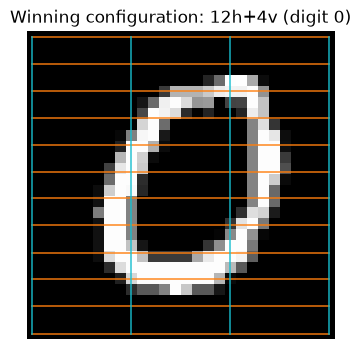

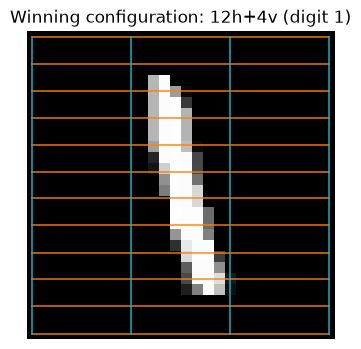

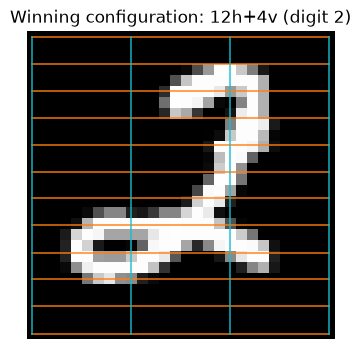

In [16]:
winning_lines = make_reference_lines(angles_deg=(0, 90), counts=(12, 4), points_per_line=32)

for digit in range(3):
    idx = (results['labels'] == digit).nonzero(as_tuple=True)[0][0].item()
    fig = plots.plot_reference_lines(
        results['images'][idx], winning_lines,
        title=f"Winning configuration: 12h+4v (digit {digit})")
    display(fig)
    plt.close(fig)

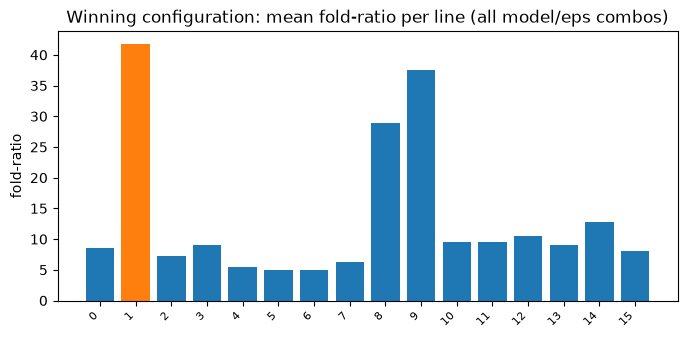

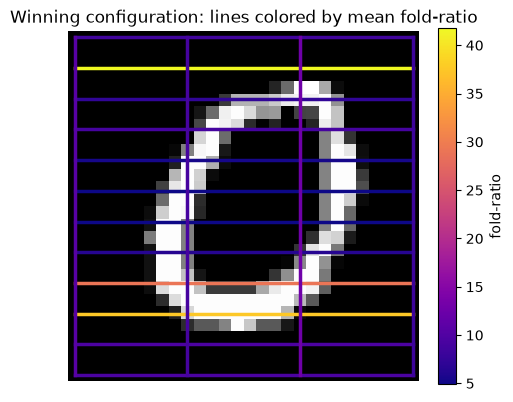

In [17]:
winning = stage_b['results']['best_combo_12h4v_depth2']
fold_by_line_winner = {i: [] for i in range(16)}
for mname in winning['models']:
    for eps in stage_b['epsilons']:
        e = winning['models'][mname]['eps'][eps]
        flip_idx = e['flip_mask'].nonzero(as_tuple=True)[0]
        if flip_idx.shape[0] == 0:
            continue
        for i in range(16):
            adv_mean = e['ratio_adv'][flip_idx, i].mean().item()
            ctrl_mean = e['ratio_control'][flip_idx, i].mean().item()
            fold_by_line_winner[i].append(adv_mean / ctrl_mean)

mean_fold_winner = {i: sum(v) / len(v) for i, v in fold_by_line_winner.items()}
best_winner_line = max(mean_fold_winner, key=mean_fold_winner.get)

fig = plots.plot_per_line_bar(
    mean_fold_winner, title="Winning configuration: mean fold-ratio per line (all model/eps combos)",
    ylabel="fold-ratio", highlight_key=best_winner_line,
)
display(fig)
plt.close(fig)

sample_idx = (results['labels'] == 0).nonzero(as_tuple=True)[0][0].item()
metric_values = [mean_fold_winner[i] for i in range(16)]
fig = plots.plot_reference_lines_with_metric(
    results['images'][sample_idx], winning_lines, metric_values,
    title="Winning configuration: lines colored by mean fold-ratio", colorbar_label="fold-ratio")
display(fig)
plt.close(fig)

## Status and recommendation

**`12h+4v, depth=2` is adopted as the new Method B default**, replacing the original
`8h+8v, depth=4` - confirmed by two independent evaluations (a cheap AUC screen and the
full per-path adversarial evaluation), and checked for robustness. Points-per-line showed
the weakest effect of any swept axis, which is the main signal this sweep offers toward
Method C's own segment-length choice (no strong case for a long segment length based on
Method B's analogous parameter).

Next: Method C, informed by what this sweep found.